In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("../").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import sys

sys.path.append('..')

from src.data_loader import DataLoader
from src.preprocessing import TimeSeriesPreprocessor
from src.forecast import FutureForecaster
from src.visualization import Visualizer

In [2]:
assets = {

    "TSLA": {

        "data": "../data/processed/TSLA_processed.csv",

        "model": "../models/TSLA_LSTM.keras"

    },

    "SPY": {

        "data": "../data/processed/SPY_processed.csv",

        "model": "../models/SPY_LSTM.keras"

    },

    "BND": {

        "data": "../data/processed/BND_processed.csv",

        "model": "../models/BND_LSTM.keras"

    }

}

In [3]:
from pathlib import Path
import os

print("Current directory:", Path.cwd())
print("Notebook exists:", Path("03_Future Market Forecasting.ipynb").exists())
print("Models folder exists:", Path("../models").exists())
print("TSLA exists:", Path("../models/TSLA_LSTM.keras").exists())

Current directory: c:\Users\habtamu.amsalu\Downloads\portfolio-optimization\notebooks
Notebook exists: True
Models folder exists: True
TSLA exists: True


In [4]:
from pathlib import Path

model = Path("../models/TSLA_LSTM.keras")

print(model)
print(model.exists())

if model.exists():
    print("Size (MB):", model.stat().st_size / 1024 / 1024)

..\models\TSLA_LSTM.keras
True
Size (MB): 0.3817729949951172


In [5]:
import tensorflow as tf

print(tf.__version__)
print(tf.keras.__version__)

2.21.0
3.15.0


In [6]:
from pathlib import Path

p = Path("../models/TSLA_LSTM.keras").resolve()

print("Exists:", p.exists())
print("File:", p)
print("Size (MB):", round(p.stat().st_size / 1024 / 1024, 2))

Exists: True
File: C:\Users\habtamu.amsalu\Downloads\portfolio-optimization\models\TSLA_LSTM.keras
Size (MB): 0.38


In [7]:
from tensorflow.keras.models import load_model
from pathlib import Path

model_path = Path("../models/TSLA_LSTM.keras").resolve()

print(model_path)

model = load_model(
    str(model_path),
    compile=False
)

print("SUCCESS!")
print(type(model))
model.summary()

C:\Users\habtamu.amsalu\Downloads\portfolio-optimization\models\TSLA_LSTM.keras
SUCCESS!
<class 'keras.src.models.sequential.Sequential'>


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
import zipfile
from pathlib import Path

model_path = Path("../models/TSLA_LSTM.keras")

print("Exists:", model_path.exists())

print("Is ZIP:", zipfile.is_zipfile(model_path))

Exists: True
Is ZIP: True


In [9]:
import h5py
from pathlib import Path

model_path = Path("../models/TSLA_LSTM.keras")

try:
    with h5py.File(model_path, "r") as f:
        print("This is an HDF5 model.")
        print("Keys:", list(f.keys()))
except Exception as e:
    print("Not an HDF5 file.")
    print(e)

Not an HDF5 file.
Unable to synchronously open file (file signature not found)


In [10]:
preprocessor = TimeSeriesPreprocessor()

forecast_results = {}

window = 60
future_days = 252

for asset, paths in assets.items():

    print("=" * 80)
    print(f"Processing {asset}")
    print("=" * 80)

    loader = DataLoader(paths["data"])
    df = loader.load_data()
    df = preprocessor.clean_data(df)

    scaler = MinMaxScaler()
    scaled_close = scaler.fit_transform(df[["Close"]])

    last_sequence = scaled_close[-window:]
    last_sequence = last_sequence.reshape(1, window, 1)

    # Create forecaster
    forecaster = FutureForecaster(paths["model"])

    # Load model
    forecaster.load()

    # Forecast
    predictions = forecaster.forecast(
        last_sequence,
        scaler,
        future_days
    )

    # Dates
    future_dates = forecaster.create_future_dates(
        df["Date"].iloc[-1],
        future_days
    )

    # Confidence intervals
    lower, upper = forecaster.confidence_intervals(
        predictions,
        df["Daily_Return"]
    )

    # Trend
    trend = forecaster.analyze_trend(predictions)

    # Opportunities / Risks
    opportunities, risks = forecaster.market_analysis(trend)

    # Save forecast
    forecast_df = forecaster.save_forecast(
        future_dates,
        predictions,
        lower,
        upper,
        f"../outputs/{asset}_future_forecast.csv"
    )

    # Store results
    forecast_results[asset] = {
        "forecast": forecast_df,
        "trend": trend,
        "opportunities": opportunities,
        "risks": risks,
        "history": df
    }

    print(trend)

Processing TSLA
Loading: C:\Users\habtamu.amsalu\Downloads\portfolio-optimization\models\TSLA_LSTM.keras
Exists : True
Loaded successfully!
{'Trend': 'Downward', 'Start Price': 375.74, 'End Price': 206.32, 'Percent Change': -45.09}
Processing SPY
Loading: C:\Users\habtamu.amsalu\Downloads\portfolio-optimization\models\SPY_LSTM.keras
Exists : True
Loaded successfully!
{'Trend': 'Stable', 'Start Price': 734.82, 'End Price': 716.16, 'Percent Change': -2.54}
Processing BND
Loading: C:\Users\habtamu.amsalu\Downloads\portfolio-optimization\models\BND_LSTM.keras
Exists : True
Loaded successfully!
{'Trend': 'Stable', 'Start Price': 73.41, 'End Price': 71.38, 'Percent Change': -2.76}




TSLA


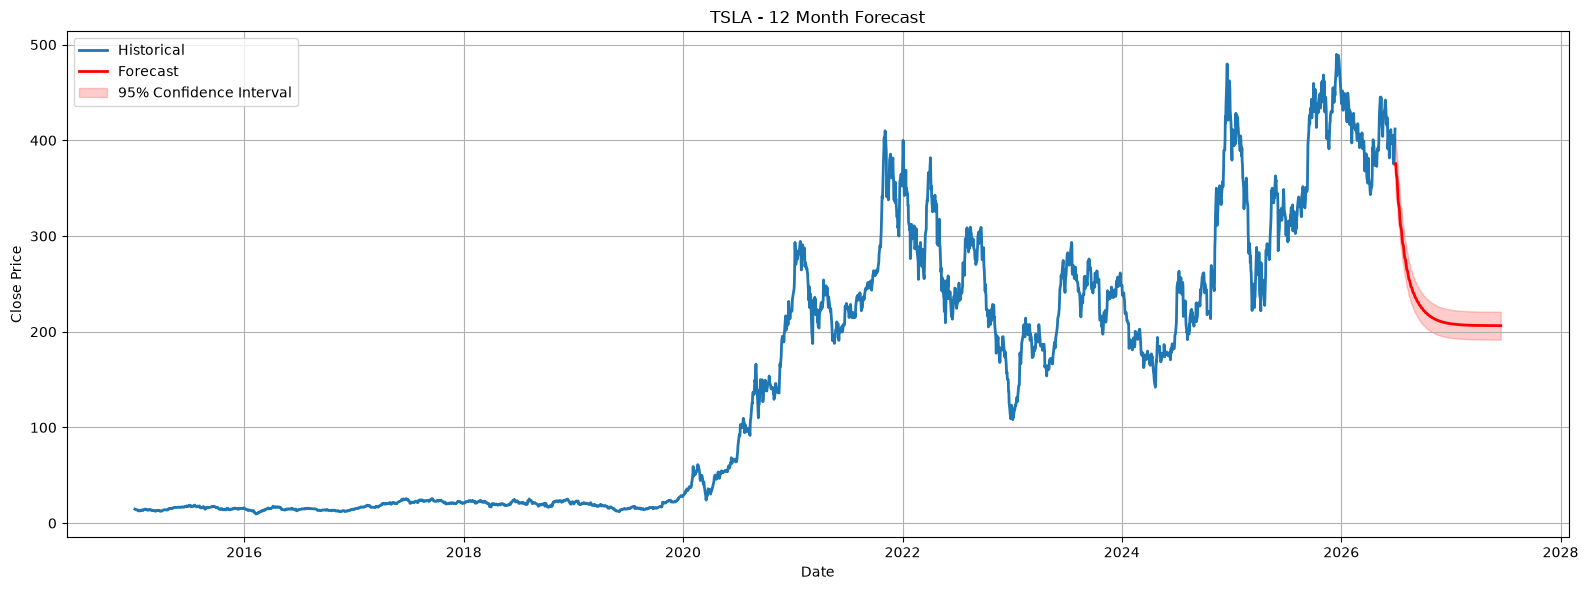



SPY


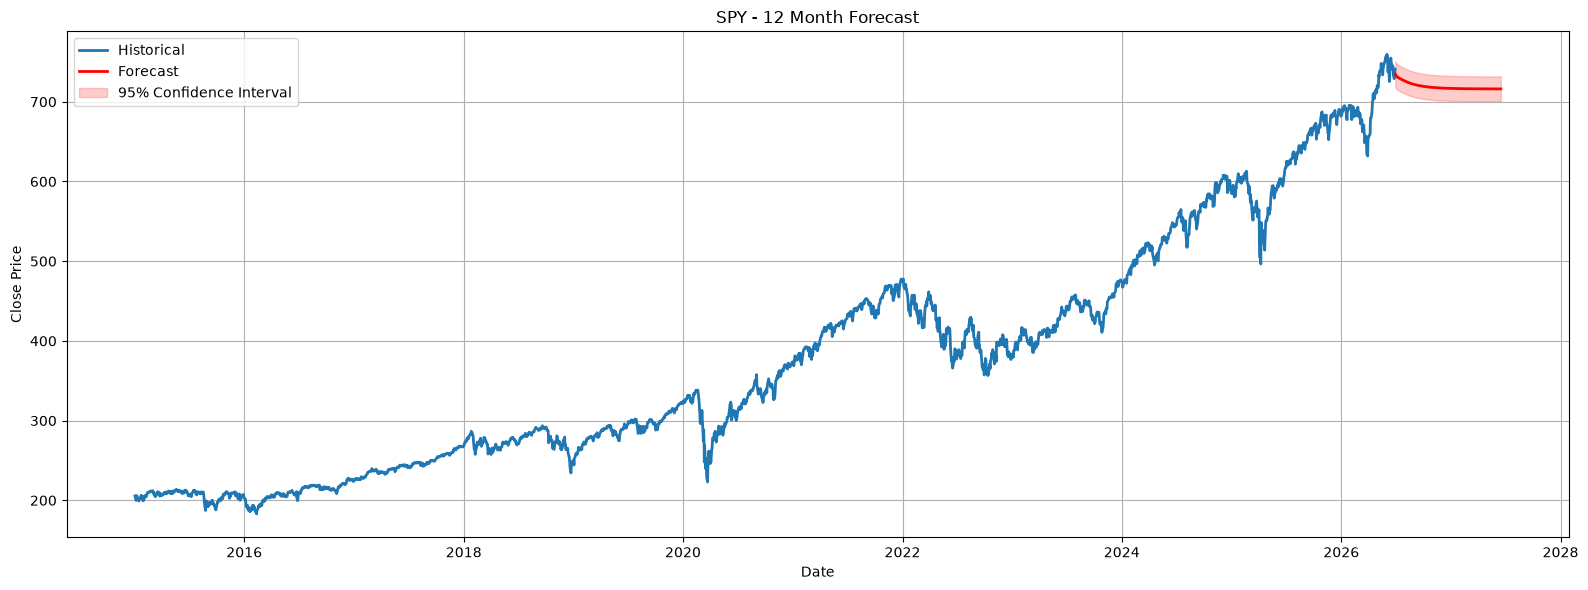



BND


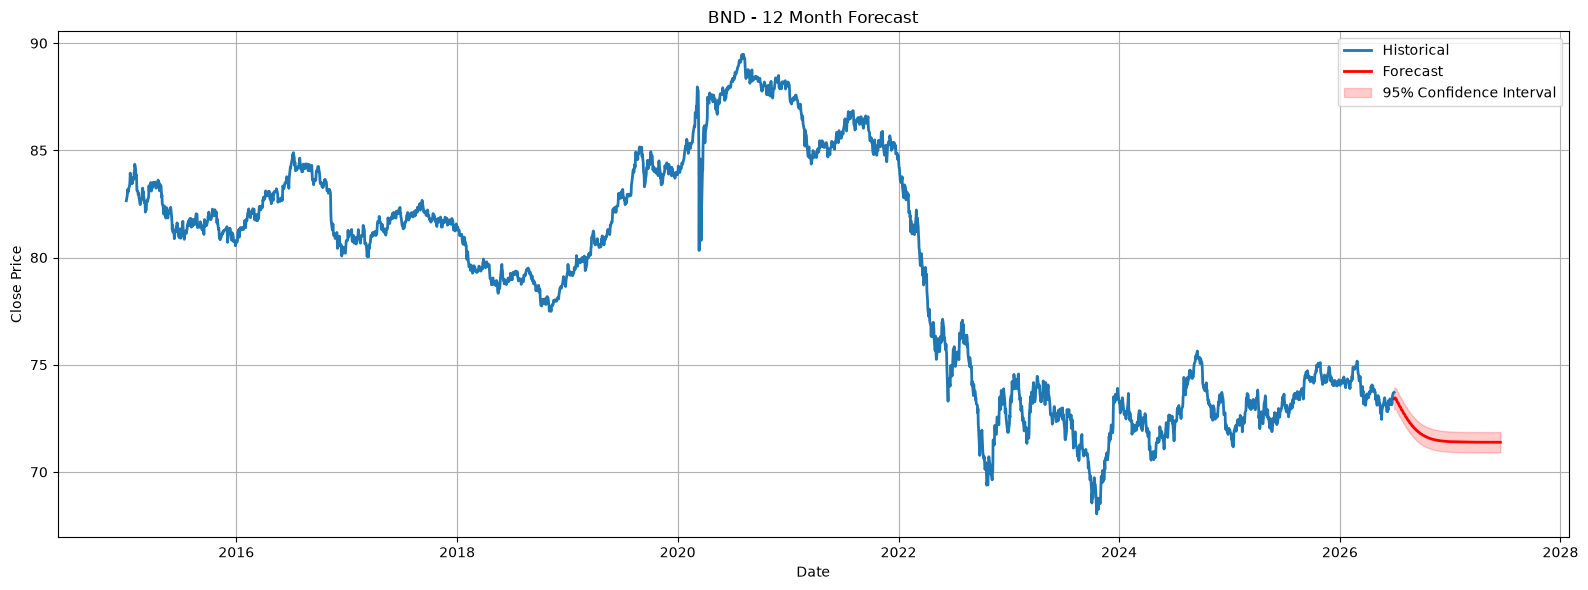

In [11]:
for asset, result in forecast_results.items():

    print("\n")

    print("=" * 80)

    print(asset)

    print("=" * 80)

    Visualizer.plot_future_forecast(

        history_dates=result["history"]["Date"],

        history_prices=result["history"]["Close"],

        future_dates=result["forecast"]["Date"],

        forecast=result["forecast"]["Forecast"],

        lower=result["forecast"]["Lower_CI"],

        upper=result["forecast"]["Upper_CI"],

        title=f"{asset} - 12 Month Forecast"

    )

In [12]:
summary = []

for asset, result in forecast_results.items():

    trend = result["trend"]

    summary.append({

        "Asset": asset,

        "Trend": trend["Trend"],

        "Start Price": trend["Start Price"],

        "End Price": trend["End Price"],

        "Percent Change": trend["Percent Change"]

    })

summary_df = pd.DataFrame(summary)

summary_df

,Asset,Trend,Start Price,End Price,Percent Change
0,TSLA,Downward,375.74,206.32,-45.09
1,SPY,Stable,734.82,716.16,-2.54
2,BND,Stable,73.41,71.38,-2.76


In [13]:
for asset, result in forecast_results.items():

    print("\n")

    print("=" * 80)

    print(asset)

    print("=" * 80)

    print("\nTrend")

    print(result["trend"])

    print("\nMarket Opportunities")

    for item in result["opportunities"]:

        print(f"• {item}")

    print("\nMarket Risks")

    for item in result["risks"]:

        print(f"• {item}")



TSLA

Trend
{'Trend': 'Downward', 'Start Price': 375.74, 'End Price': 206.32, 'Percent Change': -45.09}

Market Opportunities
• Potential buying opportunities after declines.
• Useful for value investors.

Market Risks
• Expected price decline.
• Higher downside risk.
• Possible increased volatility.


SPY

Trend
{'Trend': 'Stable', 'Start Price': 734.82, 'End Price': 716.16, 'Percent Change': -2.54}

Market Opportunities
• Stable market suitable for conservative investors.
• Lower expected volatility.

Market Risks
• Limited capital appreciation.
• Unexpected market events may change the trend.


BND

Trend
{'Trend': 'Stable', 'Start Price': 73.41, 'End Price': 71.38, 'Percent Change': -2.76}

Market Opportunities
• Stable market suitable for conservative investors.
• Lower expected volatility.

Market Risks
• Limited capital appreciation.
• Unexpected market events may change the trend.


Trend Analysis Summary
TSLA (Tesla)
The forecast for TSLA indicates a significant downward trend over the next 12 months, with an expected price decline of approximately 45.09%. The predicted start price is around 375.74, dropping to about 206.32 by the end of the forecast period. This strong bearish outlook suggests considerable risk for investors holding the stock, but could present potential buying opportunities for those looking to enter at a lower price point, assuming the model's accuracy.

SPY (S&P 500 ETF)
The forecast for SPY shows a stable trend with a slight downward bias, projecting a modest decline of about 2.54%. Starting at approximately 734.82, the price is expected to settle around 716.16. This stability, coupled with minor depreciation, suggests SPY might be suitable for more conservative investors seeking lower volatility rather than significant capital appreciation. Market risks primarily involve unexpected external events that could disrupt this stable pattern.

BND (Vanguard Total Bond Market ETF)
Similar to SPY, BND is forecasted to exhibit a stable trend, with a minor expected decline of around 2.76%. The price is projected to move from approximately 73.41 to 71.38. This indicates that BND will likely continue to be a low-volatility asset, appealing to risk-averse investors or those seeking portfolio diversification rather than substantial growth. The primary risks are limited upside potential and unforeseen economic shifts.

Critical Assessment of Forecast Reliability Over Different Time Horizons
The visualizations clearly illustrate the behavior of confidence intervals over the 6-12 month forecast horizon. For all assets (TSLA, SPY, and BND), the confidence intervals widen significantly as the forecast extends further into the future. This increasing width is a fundamental characteristic of time series forecasting and directly reflects the increasing uncertainty associated with longer-term predictions.

Implications for Reliability and Certainty:
Short-Term Reliability: In the initial weeks to a few months of the forecast horizon, the confidence intervals are relatively narrow. This suggests a higher degree of reliability and certainty in the short-term predictions. Traders and investors might find these near-term forecasts more actionable.
Long-Term Uncertainty: As the forecast extends towards the 6-12 month mark, the confidence intervals expand considerably. This implies that while a central forecast (the red line) is provided, the actual future price could reasonably fall within a much broader range. The wider intervals signify lower reliability and certainty for longer-term predictions. This is particularly evident in TSLA, where the price fluctuations are historically more pronounced, leading to a very broad confidence band over the 12-month period.
Decision Making: For strategic decision-making, it is crucial to acknowledge this increasing uncertainty. Long-term investment strategies based on these forecasts should be approached with caution, recognizing the wide range of potential outcomes. The widening bands suggest that fundamental changes or unexpected market events can have a greater impact on the actual price when looking further out. Conversely, the more constrained short-term intervals offer a firmer basis for tactical adjustments.

In [14]:
summary_df.to_csv(

    "../outputs/future_forecast_summary.csv",

    index=False

)

print("Forecast summary saved successfully.")

Forecast summary saved successfully.
